# 🚦 Helmet Detection using YOLOv8 (Object Detection Project)

## 📌 Project Overview
This project implements an object detection system to detect:
- Number Plates
- Riders
- Helmets (Good / Bad)
- No Helmet cases

The model is trained using YOLOv8 on a custom dataset sourced from Kaggle.

---

## 🧠 Objective
To build a real-time object detection model for road safety analysis that can identify whether a rider is wearing a helmet or not, along with related objects like riders and number plates.

---

## 📂 Dataset
- Source: Kaggle (Indian Helmet Detection Dataset)
- Format: YOLO annotation format
- Classes: 5 (NumberPlate, NoHelmet, GoodHelmet, BadHelmet, Rider)

---

## ⚙️ Model Used
- YOLOv8 Nano (ultralytics)
- Pretrained weights fine-tuned on custom dataset
- Trained using GPU (Google Colab T4)

---

## 🚀 Workflow
1. Dataset extraction and verification  
2. Label and image inspection  
3. Model training using YOLOv8  
4. Evaluation using mAP metrics  
5. Testing on unseen images  

---

## 📊 Output
The model successfully detects multiple classes in real-world images with satisfactory accuracy and bounding box predictions.

---

## 👨‍💻 Tools Used
- Python
- Google Colab
- YOLOv8 (Ultralytics)
- OpenCV
- TensorFlow (environment support)

---

## 📌 Note
This notebook contains full code implementation and outputs as required for internship submission.

In [7]:
import tensorflow as tf

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


In [11]:
import zipfile

zip_path = "/content/archive.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/helmet_dataset")

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [12]:
import os

print(os.listdir("/content/helmet_dataset"))

['README.roboflow.txt', 'valid', 'train', 'README.dataset.txt', 'data.yaml']


In [4]:
import os

image_folder = "/content/helmet_dataset/train/images"
label_folder = "/content/helmet_dataset/train/labels"

print("Number of images:", len(os.listdir(image_folder)))
print("Number of labels:", len(os.listdir(label_folder)))

Number of images: 800
Number of labels: 800


In [13]:
import os

label_folder = "/content/helmet_dataset/train/labels"

sample_label = os.listdir(label_folder)[0]

print("File:", sample_label)

with open(os.path.join(label_folder, sample_label), "r") as f:
    print(f.read())

File: 033_049_jpg.rf.db2e90f0a376ca9b629c02c6750576bc.txt
0 0.69375 0.65234375 0.109375 0.0546875
2 0.465625 0.42734375 0.14140625 0.146875
4 0.53984375 0.62578125 0.48828125 0.6375


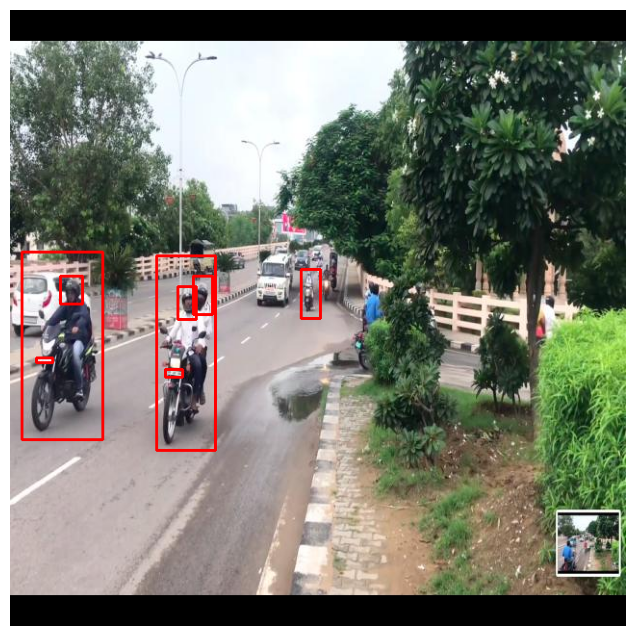

In [14]:
import os
import cv2
import matplotlib.pyplot as plt

image_folder = "/content/helmet_dataset/train/images"
label_folder = "/content/helmet_dataset/train/labels"

image_name = os.listdir(image_folder)[0]

image_path = os.path.join(image_folder, image_name)

image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

h, w, _ = image.shape

label_name = image_name.rsplit(".", 1)[0] + ".txt"
label_path = os.path.join(label_folder, label_name)

with open(label_path, "r") as f:
    labels = f.readlines()

for line in labels:
    cls, x, y, bw, bh = map(float, line.split())

    x1 = int((x - bw / 2) * w)
    y1 = int((y - bh / 2) * h)
    x2 = int((x + bw / 2) * w)
    y2 = int((y + bh / 2) * h)

    cv2.rectangle(image, (x1, y1), (x2, y2), (255, 0, 0), 2)

plt.figure(figsize=(10, 8))
plt.imshow(image)
plt.axis("off")
plt.show()

In [15]:
import os

label_folder = "/content/helmet_dataset/train/labels"

found_classes = set()

for file in os.listdir(label_folder):
    with open(os.path.join(label_folder, file), "r") as f:
        for line in f:
            class_id = int(line.split()[0])
            found_classes.add(class_id)

print("Classes found:", sorted(found_classes))

Classes found: [0, 1, 2, 3, 4]


In [16]:
import tensorflow as tf

print("GPU Available:", tf.config.list_physical_devices('GPU'))

GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [17]:
import os
import cv2

image_folder = "/content/helmet_dataset/train/images"

sample_image = os.listdir(image_folder)[0]

img = cv2.imread(
    os.path.join(image_folder, sample_image)
)

print("Shape:", img.shape)

Shape: (640, 640, 3)


In [18]:
from collections import Counter
import os

label_folder = "/content/helmet_dataset/train/labels"

class_counts = Counter()

for file in os.listdir(label_folder):
    with open(os.path.join(label_folder, file), "r") as f:
        for line in f:
            class_id = int(line.split()[0])
            class_counts[class_id] += 1

print(class_counts)

Counter({2: 1787, 4: 1750, 0: 1327, 1: 791, 3: 293})


In [19]:
CLASS_NAMES = {
    0: "NumberPlate",
    1: "NoHelmet",
    2: "GoodHelmet",
    3: "BadHelmet",
    4: "Rider"
}

print(CLASS_NAMES)

{0: 'NumberPlate', 1: 'NoHelmet', 2: 'GoodHelmet', 3: 'BadHelmet', 4: 'Rider'}


In [20]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 35.4 MB/s eta 0:00:00


In [21]:
from ultralytics import YOLO

print("YOLO installed successfully")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
YOLO installed successfully


In [22]:
import os

print(os.listdir("/content/helmet_dataset"))

['README.roboflow.txt', 'valid', 'train', 'README.dataset.txt', 'data.yaml']


In [23]:
print(len(os.listdir("/content/helmet_dataset/train/images")))
print(len(os.listdir("/content/helmet_dataset/valid/images")))

800
142


In [24]:
with open("/content/helmet_dataset/data.yaml", "r") as f:
    print(f.read())

train: ../train/images
val: ../valid/images
test: ../test/images

nc: 5
names: ['0', '1', '2', '3', '4']

roboflow:
  workspace: yolo-ftygl
  project: aryan_1
  version: 1
  license: CC BY 4.0
  url: https://universe.roboflow.com/yolo-ftygl/aryan_1/dataset/1


In [25]:
yaml_content = """
train: /content/helmet_dataset/train/images
val: /content/helmet_dataset/valid/images

nc: 5
names: ['NumberPlate', 'NoHelmet', 'GoodHelmet', 'BadHelmet', 'Rider']
"""

with open("/content/helmet_dataset/data.yaml", "w") as f:
    f.write(yaml_content)

print("data.yaml FIXED successfully")

data.yaml FIXED successfully


In [26]:
from ultralytics import YOLO

# Load small, fast model (best for your laptop + Colab)
model = YOLO("yolov8n.pt")

# Start training
model.train(
    data="/content/helmet_dataset/data.yaml",
    epochs=50,
    imgsz=640,
    batch=16,
    device=0,
    name="helmet_yolo_v8n"
)

Ultralytics 8.4.66 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/helmet_dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=helmet_yolo_v8n, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, pa

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7e726ae3a060>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
        

In [28]:
from ultralytics import YOLO

model = YOLO("/content/runs/detect/helmet_yolo_v8n/weights/best.pt")

In [29]:
from ultralytics import YOLO
import os

# load model (already loaded, but safe to re-load)
model = YOLO("/content/runs/detect/helmet_yolo_v8n/weights/best.pt")

# pick one test image
img_folder = "/content/helmet_dataset/valid/images"
img_name = os.listdir(img_folder)[0]
img_path = os.path.join(img_folder, img_name)

print("Testing on:", img_path)

# run prediction
results = model(img_path, save=True, conf=0.25)

Testing on: /content/helmet_dataset/valid/images/098-Rhythm175_jpg.rf.684b83aa27bd078f16859e07db9ba54d.jpg

image 1/1 /content/helmet_dataset/valid/images/098-Rhythm175_jpg.rf.684b83aa27bd078f16859e07db9ba54d.jpg: 640x640 4 NumberPlates, 4 NoHelmets, 5 GoodHelmets, 1 BadHelmet, 4 Riders, 8.3ms
Speed: 5.6ms preprocess, 8.3ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict


In [30]:
from ultralytics import YOLO
import os

# load your trained model
model = YOLO("/content/runs/detect/helmet_yolo_v8n/weights/best.pt")

# pick 5 random images from validation set
img_folder = "/content/helmet_dataset/valid/images"
images = os.listdir(img_folder)[:5]

for img_name in images:
    img_path = os.path.join(img_folder, img_name)

    print("Running on:", img_name)

    results = model(img_path, save=True, conf=0.25)

Running on: 098-Rhythm175_jpg.rf.684b83aa27bd078f16859e07db9ba54d.jpg

image 1/1 /content/helmet_dataset/valid/images/098-Rhythm175_jpg.rf.684b83aa27bd078f16859e07db9ba54d.jpg: 640x640 4 NumberPlates, 4 NoHelmets, 5 GoodHelmets, 1 BadHelmet, 4 Riders, 8.2ms
Speed: 2.1ms preprocess, 8.2ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict-2
Running on: 013_9_jpeg.rf.6f496b14ed3858d1ff052229fa579e25.jpg

image 1/1 /content/helmet_dataset/valid/images/013_9_jpeg.rf.6f496b14ed3858d1ff052229fa579e25.jpg: 640x640 1 NoHelmet, 3 GoodHelmets, 3 Riders, 7.2ms
Speed: 2.0ms preprocess, 7.2ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict-2
Running on: Screenshot-2023-08-02-172037_png_jpg.rf.3ba89738999ff3d1eec182e7d890dffb.jpg

image 1/1 /content/helmet_dataset/valid/images/Screenshot-2023-08-02-172037_png_jpg.rf.3ba89738999ff3d1eec182e7d890dffb.jpg: 640x640 1 GoodHelmet, 1 R